In [61]:
import sqlite3
import json

with sqlite3.connect("datasheets/datasheet_tracker") as conn:
    conn.row_factory = sqlite3.Row
    rows = conn.execute("SELECT * FROM datasheet_tracker").fetchall()
    entries = [dict(row) for row in rows]

In [62]:
symbol_json_path = "test_cases/test_audio_amplifier/symbols/94e6638093ff4ff4bc5663dba417b306.json"

with open(symbol_json_path, "r") as f:
    symbol_json = json.load(f)

name = symbol_json["name"]

for row in entries:
    if row["symbol_name"] == name:
        lib = row["library"]
        break

print(name)
print(lib)

TPS62087RLTR
Power_Supply_Chip


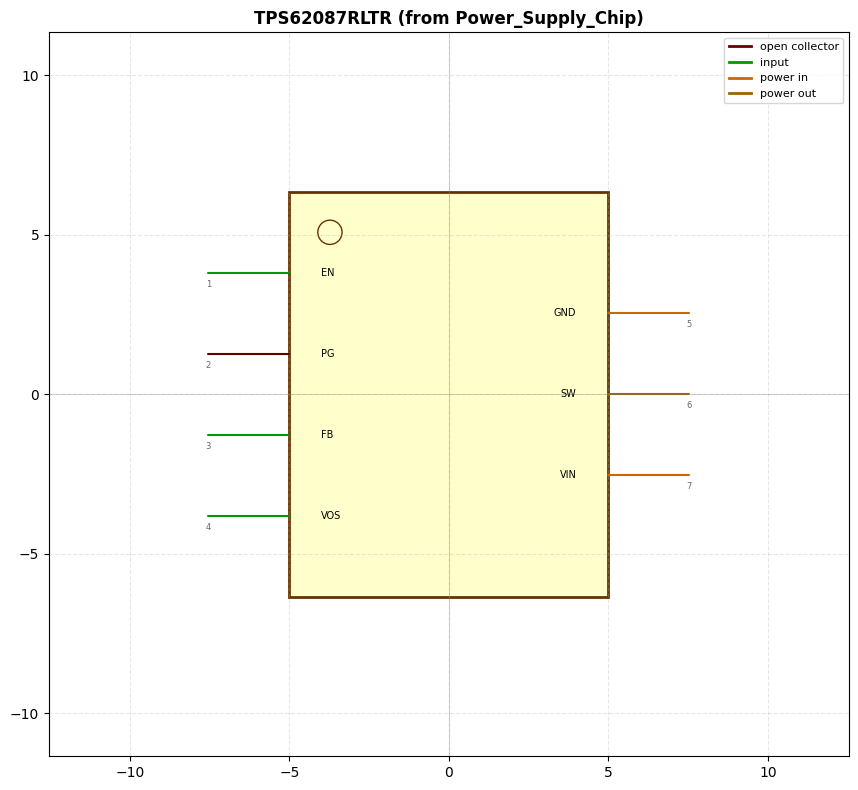

In [63]:
from python.commands.database_tools.symbol_visualizer import visualize_by_mpn

s = visualize_by_mpn(name, lib, show=False)

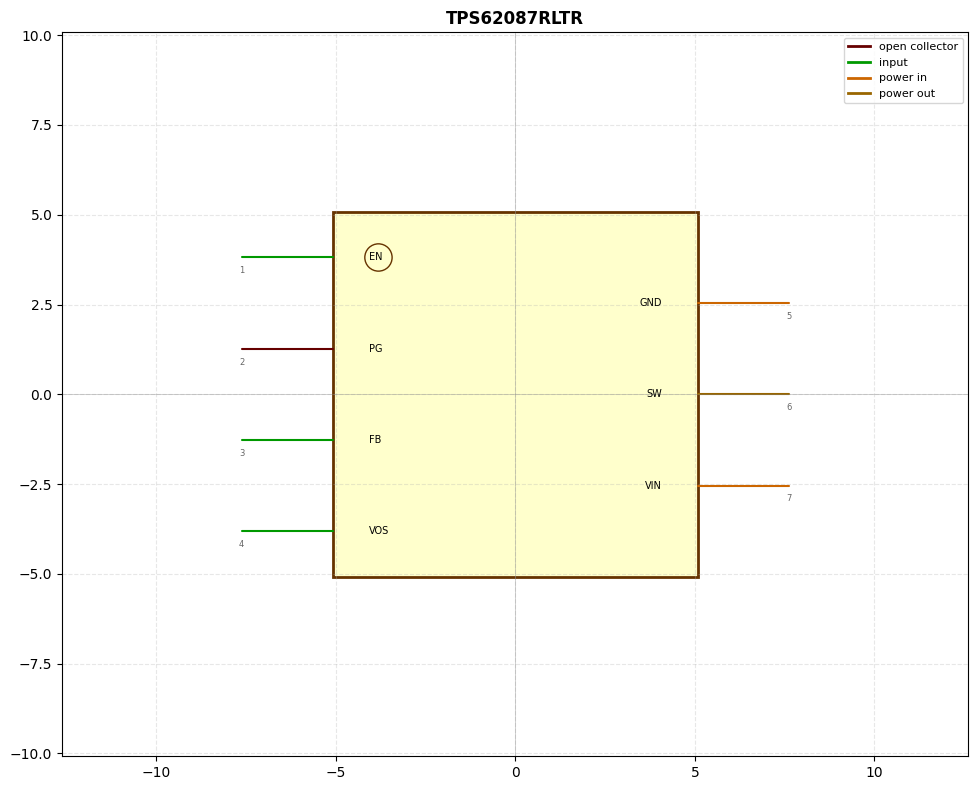

In [64]:
from python.commands.database_tools.symbol_builders import build_symbol_from_json
from python.commands.database_tools.symbol_visualizer import visualize_symbol

sexp = build_symbol_from_json(symbol_json)
fig = visualize_symbol(sexp, show=False)

In [65]:
from python.commands.database_tools.library_schematic import LibraryManager
result = LibraryManager.add_symbol_entry({
    "mpn": name,
    "library": lib,
    "sexp": sexp,
    "overwrite": True,
})
print(result)

{'success': True, 'message': 'Updated symbol TPS62087RLTR in library Power_Supply_Chip', 'mpn': 'TPS62087RLTR', 'library': 'Power_Supply_Chip', 'dbPath': '/root/workspace/KiCAD_MCP/symbol_lib/kicad_symbols.sqlite3'}


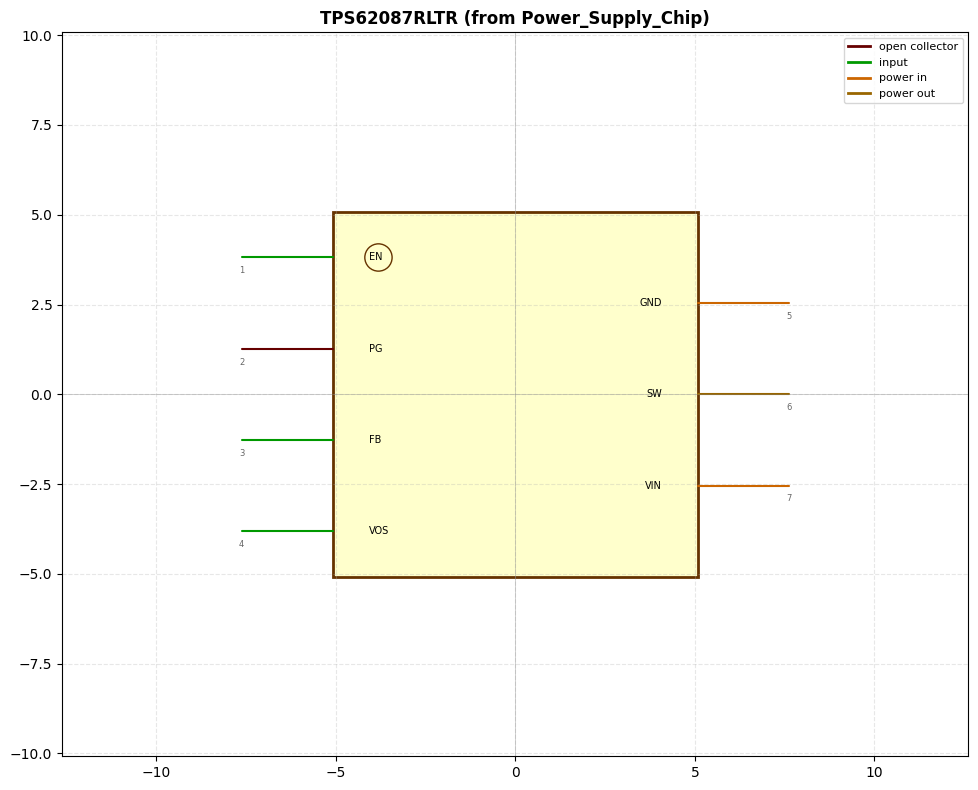

In [67]:
s1 = visualize_by_mpn(name, lib, show=False)